# Adjoints and Backprop, Part 1: What is an adjoint method?

*This is the first part of a short series. Part 1 introduces adjoint methods using a ball in flight. Part 2 introduces backpropagation, and Part 3 shows that backpropagation **is** an adjoint method: the same algorithm under a different name.*

Suppose you have a computation that runs for many steps (a physics simulation, a control system, a neural network), and it depends on inputs you get to choose. At the end it produces some outputs, and you score them with a single number: a mismatch with observations, a control cost (miss distance plus fuel used), or a training loss. You'd like to know how to change the inputs to make that number better, so you go looking for its **gradient** with respect to every input.

The adjoint method computes that gradient exactly, at a cost of roughly two runs of the computation, one forward and one backward, **no matter how many inputs there are.** It's how weather models with millions of unknowns get fitted to data, how wing shapes get optimized, and (as we'll see in Part 3) how neural networks get trained.

**What you need:** multivariable calculus (the chain rule, Jacobians), a little linear algebra, and basic Python. 

**In this part:**

1. The problem: gradients of long computations
2. The idea: the chain rule, multiplied in a clever order
3. Example A: throwing a ball (2 inputs)
4. Example B: steering with thrusters (600 inputs)
5. Recap

In [28]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import minimize

# Plot style. The series colours are chosen to stay distinguishable for colour-blind readers.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#1d1d1b", "#52514e", "#e7e6e2", "#fcfcfb"
OBST_FILL, OBST_EDGE = "#dcdad5", "#8a8984"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 12, "axes.titlesize": 12.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "lines.linewidth": 2, "legend.frameon": False, "legend.fontsize": 11,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA]),
})
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])

## 1. The problem: gradients of long computations

Many computations we care about have the same shape. There's a **state** $s \in \mathbb{R}^n$ (positions and velocities, say) that gets updated step by step,
$$ s_{k+1} = \Phi(s_k), \qquad k = 0, 1, \dots, N-1, $$
starting from an initial state $s_0$ that depends on some **inputs** $\theta \in \mathbb{R}^p$ that we choose. At the end we score the result with a single number,
$$ J = \Psi(s_N). $$
We want $\nabla_\theta J$, which tells us how to modify each input to lower the score.

The simplest idea is **finite differences**. Nudge one input by a small amount $\varepsilon$, rerun the whole computation, and see how much $J$ moved:
$$ \frac{\partial J}{\partial \theta_i} \approx \frac{J(\theta + \varepsilon e_i) - J(\theta)}{\varepsilon}. $$
It's easy, and it works on any code. It does have some immediate shortcomings:

Using finite differences requires one rerun per input, so $p + 1$ simulations per gradient calculation. This is extremely prohibitive when the number of inputs is large. There's also the problem of picking an appropriate $\varepsilon$. If $\varepsilon$ is too large, the linear approximation will be poor, and if it's too small then floating-point cancellation could be a problem.

The adjoint method fixes both of these problems! However, we will see it does come with its own collection of drawbacks.

## 2. The idea: the chain rule, multiplied in a clever order

Write $A_k = \partial\Phi/\partial s$ evaluated at $s_k$ for the Jacobian of one step (an $n \times n$ matrix), and $D = \partial s_0/\partial\theta$ for how the inputs set the initial state (an $n \times p$ matrix). The chain rule says the gradient is a long product:
$$ \frac{dJ}{d\theta} = \underbrace{\nabla \Psi(s_N)^\top}_{1 \times n} \; \underbrace{A_{N-1}\, A_{N-2} \cdots A_0}_{\text{each } n \times n} \; \underbrace{D}_{n \times p}. $$

 Since matrix multiplication is associative, we get to choose the order, and the two natural orders introduce two different methods.

**Right to left ("forward mode").** Start with $D$ and push it through the steps: $A_0 D$, then $A_1 (A_0 D)$, and so on. You carry an $n \times p$ matrix forward alongside the simulation, one column per input. The cost is about $N n^2 p$. This tracks how each input's influence spreads, and it's essentially finite differences done exactly. It still scales with the number of inputs.

**Left to right ("reverse mode", the adjoint method).** Start with the row vector $\nabla \Psi(s_N)^\top$ and pull it backward: multiply by $A_{N-1}$, then $A_{N-2}$, and so on down to $A_0$. You only ever carry **one vector of length $n$**. The cost is about $N n^2$, plus one multiplication by $D$ at the very end. The number of inputs barely matters.

That backward-traveling vector is the **adjoint**. Written as a column vector $\lambda_k$, it's defined by
$$ \lambda_k^\top = \nabla \Psi(s_N)^\top A_{N-1} \cdots A_k, $$
which gives a backward recursion:
$$ \boxed{\;\lambda_N = \nabla \Psi(s_N), \qquad \lambda_k = A_k^\top \lambda_{k+1}, \qquad \frac{dJ}{d\theta} = D^\top \lambda_0\;} $$

The transposes are where the name comes from-- Multiplying a matrix on the left by a row vector, $v^\top A$, is the same as multiplying the column vector by the transpose, $A^\top v$, and the transpose of a linear map is often referred to as its *adjoint*.

**What the adjoint means.** $\lambda_k$ is exactly $\partial J/\partial s_k$: how much the final score would change if something nudged the state at step $k$ and the simulation carried on from there. For a ball in flight, it answers the question *"if a gust of wind bumped the ball at time $t$, how much more would it miss by?"* That question has an answer at every moment of the flight, and the backward sweep computes all of them in one pass.

**The catch.** The Jacobians $A_k$ depend on the states $s_k$, and the backward sweep needs them in reverse order. So you run the simulation forward first, store the trajectory, then sweep backward. The price of the adjoint method is memory, not time. (For very long simulations there are standard tricks, such as storing only occasional checkpoints and recomputing the states in between.)

| Method | Inputs handled | Cost per gradient | Accuracy |
|---|---|---|---|
| Finite differences | one at a time | $p + 1$ simulations | approximate |
| Forward mode | one at a time, exactly | about $p$ extra sweeps | exact |
| **Adjoint (reverse mode)** | **all at once** | **1 forward + 1 backward sweep** | **exact** |

<details>
<summary><b>Going deeper:</b> the Lagrange-multiplier derivation, and the continuous-time adjoint</summary>

A second way to get the same recursion is to treat each simulation step as a constraint and attach a Lagrange multiplier to it:
$$ \mathcal{L} = \Psi(s_N) - \sum_{k=0}^{N-1} \lambda_{k+1}^\top \big(s_{k+1} - \Phi(s_k)\big) - \lambda_0^\top \big(s_0 - s_0(\theta)\big). $$
Whenever the states obey the simulation, the bracketed terms vanish and $\mathcal{L} = J$, whatever the $\lambda$'s are. Now differentiate with respect to $\theta$ and choose the $\lambda$'s so that every term containing $ds_k/d\theta$ cancels. What survives is exactly the boxed recursion. This view generalizes best (to constraints, control problems and continuous time), and it's why the adjoint is also called the *multiplier* or, in control theory, the *costate*.

For continuous time, suppose each step is a forward-Euler step of an ODE $\dot s = f(s)$, so that $\Phi(s) = s + h f(s)$. Then $A_k = I + h\, \partial f/\partial s$, and the recursion rearranges to
$$ \frac{\lambda_{k+1} - \lambda_k}{h} = -\left(\frac{\partial f}{\partial s}\right)^{\!\top} \lambda_{k+1}. $$
As $h \to 0$ this becomes the **adjoint ODE** $\dot\lambda = -(\partial f/\partial s)^\top \lambda$, solved backward in time from $\lambda(T) = \nabla \Psi(s(T))$. Whether you should discretize this adjoint ODE, or differentiate the discrete simulation directly as we do below, turns out to matter. That's a story for Part 3.

</details>

## 3. Example A: throwing a ball (2 inputs)

**A toy problem.** Imagine you're attempting to throw a ball to a friend who's standing on a ledge 25 m away and 3 m up, and who will catch it exactly 2 seconds after you let go. You have control over precisely two things: the **launch speed** $v_0$ and the **launch angle** $\alpha$. Which throw puts the ball in their hands?

Without air resistance you could solve this on paper. With it you can't, which is why we need a simulation, and a gradient to steer it. We use quadratic drag, the standard model for a ball moving through air:
$$ \dot{\mathbf p} = \mathbf v, \qquad \dot{\mathbf v} = -g\,\hat{\mathbf y} - c\,|\mathbf v|\,\mathbf v. $$
Here $\mathbf p = (x, y)$ is the position, $\mathbf v = (v_x, v_y)$ is the velocity, $g = 9.81\ \text{m/s}^2$, and $c = 0.02\ \text{m}^{-1}$ sets the strength of the drag.

We'll glue everything into one state vector, $s = (x, y, v_x, v_y)$. The equations of motion take the form $\dot s = f(s)$, where
$$ f(s) = \begin{pmatrix} v_x \\ v_y \\ -c\,|\mathbf v|\,v_x \\ -g - c\,|\mathbf v|\,v_y \end{pmatrix}, \qquad |\mathbf v| = \sqrt{v_x^2 + v_y^2}. $$
The inputs set the initial state: $s_0 = (0,\ 0,\ v_0\cos\alpha,\ v_0\sin\alpha)$. We step forward from the throw to the catch time $T = 2$ s with the simplest method there is, forward Euler, using $N = 200$ steps of size $h = T/N$:
$$ s_{k+1} = s_k + h\, f(s_k). $$
In the language of Section 2, the step map is $\Phi(s) = s + h f(s)$.

The "score" we assign at the end of this simulation is half the squared miss distance at the catch time, where $\mathbf p_N$ is the position part of $s_N$:
$$ J(v_0, \alpha) = \Psi(s_N) = \tfrac12\, \big|\mathbf p_N - \mathbf p^*\big|^2, \qquad \mathbf p^* = (25,\ 3)\ \text{m}. $$

[Why a fixed catch time? It keeps the number of steps fixed. Handling a landing time that itself depends on the inputs is possible, but it adds a correction term that would distract from the main idea.]

In [29]:
# ---- Example A: setup ----
g = 9.81                        # gravity, m/s^2
c = 0.02                        # drag coefficient, 1/m
T = 2.0                         # catch time, s
N = 200                         # number of time steps
h = T / N                       # step size, s
p_star = np.array([25.0, 3.0])  # where the friend catches the ball, m

def f(s):
    # Right-hand side of the ODE for s = (x, y, vx, vy). Also works on whole arrays of states.
    x, y, vx, vy = s
    speed = np.sqrt(vx**2 + vy**2)
    return np.array([vx, vy, -c * speed * vx, -g - c * speed * vy])

def initial_state(theta):
    v0, alpha = theta
    zero = 0 * v0
    return np.array([zero, zero, v0 * np.cos(alpha), v0 * np.sin(alpha)])

def simulate(theta):
    # Forward Euler. Returns the whole trajectory, shape (N+1, 4).
    s = initial_state(theta)
    traj = [s]
    for k in range(N):
        s = s + h * f(s)
        traj.append(s)
    return np.array(traj)

def J(theta):
    s_N = simulate(theta)[-1]
    return 0.5 * np.sum((s_N[:2] - p_star)**2)

Here's a first guess, 18 m/s at 40°. It falls short and low.

J(first guess) = 7.974   (miss distance 3.99 m)


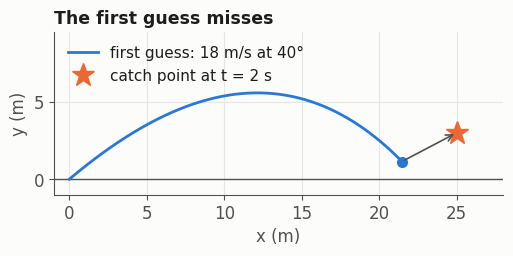

In [30]:
theta_guess = np.array([18.0, np.radians(40)])
traj = simulate(theta_guess)

fig, ax = plt.subplots(figsize=(5.8, 3.3))
ax.axhline(0, color=INK2, lw=1)
ax.plot(traj[:, 0], traj[:, 1], color=BLUE, label="first guess: 18 m/s at 40°")
ax.plot(*traj[-1, :2], "o", color=BLUE, ms=7)
ax.plot(*p_star, marker="*", ms=17, color=ORANGE, ls="none", label="catch point at t = 2 s")
ax.annotate("", xy=p_star, xytext=traj[-1, :2], arrowprops=dict(arrowstyle="->", color=INK2, lw=1.2))
ax.set(xlabel="x (m)", ylabel="y (m)", title="The first guess misses", xlim=(-1, 28), ylim=(-1, 9.5))
ax.set_aspect("equal")
ax.legend(loc="upper left")
print(f"J(first guess) = {J(theta_guess):.3f}   (miss distance {np.sqrt(2 * J(theta_guess)):.2f} m)")

### Computing the gradient with the adjoint

We need the three ingredients from Section 2.

1. **The step Jacobian.** For forward Euler, $A_k = I + h\,\partial f/\partial s$, evaluated at $s_k$. The only non-trivial part is the drag. Differentiating $|\mathbf v|\,\mathbf v$ with respect to $\mathbf v$ gives $|\mathbf v|\, I + \mathbf v \mathbf v^\top/|\mathbf v|$, so in $2 \times 2$ blocks
$$ \frac{\partial f}{\partial s} = \begin{pmatrix} 0 & I \\ 0 & -c\left(|\mathbf v|\, I + \dfrac{\mathbf v \mathbf v^\top}{|\mathbf v|}\right) \end{pmatrix}. $$
2. **The starting value.** $\lambda_N = \nabla \Psi(s_N) = (\mathbf p_N - \mathbf p^*,\ 0,\ 0)$. The final velocity doesn't affect the score, so its part of the adjoint starts at zero.
3. **The input Jacobian.** $D = \partial s_0/\partial(v_0, \alpha)$, which only touches the velocity rows:
$$ D = \begin{pmatrix} 0 & 0 \\ 0 & 0 \\ \cos\alpha & -v_0 \sin\alpha \\ \sin\alpha & v_0 \cos\alpha \end{pmatrix}. $$

Then run forward, sweep $\lambda_k = A_k^\top \lambda_{k+1}$ backward, and finish with $D^\top\lambda_0$. The whole algorithm is the short function `gradient_adjoint` below.

In [31]:
def df_ds(s):
    # Jacobian of f with respect to the state (4x4).
    v = s[2:]
    speed = np.linalg.norm(v)
    M = np.zeros((4, 4))
    M[0, 2] = M[1, 3] = 1.0
    M[2:, 2:] = -c * (speed * np.eye(2) + np.outer(v, v) / speed)
    return M

def ds0_dtheta(theta):
    # D: how (v0, alpha) set the initial state (4x2).
    v0, alpha = theta
    D = np.zeros((4, 2))
    D[2] = [np.cos(alpha), -v0 * np.sin(alpha)]
    D[3] = [np.sin(alpha),  v0 * np.cos(alpha)]
    return D

def gradient_adjoint(theta):
    traj = simulate(theta)                   # 1. forward pass, keeping the trajectory
    lam = np.zeros((N + 1, 4))
    lam[N, :2] = traj[N, :2] - p_star        # 2. starting value at the final step
    for k in reversed(range(N)):             # 3. backward pass
        A_k = np.eye(4) + h * df_ds(traj[k])
        lam[k] = A_k.T @ lam[k + 1]
    grad = ds0_dtheta(theta).T @ lam[0]      # 4. map back to the inputs
    return grad, traj, lam

### Checking it

As a sanity check, we can compare our gradients against two references.

- **Finite differences** from Section 1, at a whole range of step sizes $\varepsilon$.
- **The complex-step derivative**, a common trick of the trade: evaluate $J(\theta + i\varepsilon e_j)$ with a tiny *imaginary* step; then $\partial J/\partial\theta_j \approx \operatorname{Im} J(\theta + i\varepsilon e_j)/\varepsilon$. There's no subtraction, so there's no cancellation, and with $\varepsilon = 10^{-30}$ it's accurate to machine precision. It works here because every operation in `simulate` has a natural complex extension. It makes a great reference, but like finite differences it costs one full run per input.

In [32]:
grad_adj, traj, lam = gradient_adjoint(theta_guess)

# Reference: the complex-step derivative (one complex-valued simulation per input)
eps_cs = 1e-30
grad_cs = np.array([J(theta_guess + 1j * eps_cs * e).imag / eps_cs for e in np.eye(2)])

# Forward finite differences over a sweep of step sizes
epsilons = np.logspace(-13, -1, 49)
fd_err = []
for eps in epsilons:
    grad_fd = np.array([(J(theta_guess + eps * e) - J(theta_guess)) / eps for e in np.eye(2)])
    fd_err.append(np.linalg.norm(grad_fd - grad_cs) / np.linalg.norm(grad_cs))
adj_err = np.linalg.norm(grad_adj - grad_cs) / np.linalg.norm(grad_cs)

print("                   dJ/dv0            dJ/dalpha")
print(f"adjoint        {grad_adj[0]:+.12f}   {grad_adj[1]:+.12f}")
print(f"complex step   {grad_cs[0]:+.12f}   {grad_cs[1]:+.12f}")
print(f"relative difference: {adj_err:.1e}")

                   dJ/dv0            dJ/dalpha
adjoint        -4.960817792198   +17.081691341126
complex step   -4.960817792198   +17.081691341126
relative difference: 4.8e-15


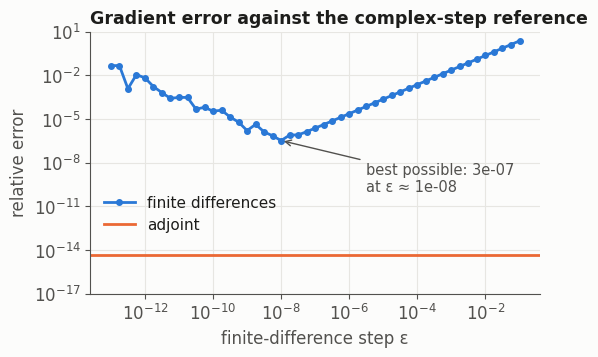

In [33]:
fig, ax = plt.subplots(figsize=(5.8, 3.4))
ax.loglog(epsilons, fd_err, color=BLUE, marker="o", ms=4, label="finite differences")
ax.axhline(max(adj_err, 1e-16), color=ORANGE, label="adjoint")
best = int(np.argmin(fd_err))
ax.annotate(f"best possible: {fd_err[best]:.0e}\nat ε ≈ {epsilons[best]:.0e}", xy=(epsilons[best], fd_err[best]),
            xytext=(epsilons[best] * 3e2, fd_err[best] * 3e-4), color=INK2, fontsize=10.5,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=1))
ax.set(xlabel="finite-difference step ε", ylabel="relative error", ylim=(1e-17, 10),
       title="Gradient error against the complex-step reference")
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.18))

The finite-difference error bottoms out around $10^{-7}$ at the best step size and gets worse on either side: too large and the linear approximation is off, too small and rounding error wins. The adjoint agrees with the complex-step reference to about 15 digits. It's the **exact** derivative of the computation we actually ran, up to rounding.

*Note:* "the computation we actually ran" is the Euler simulation, not the true ODE. That distinction becomes important in Part 3.

### What the adjoint looks like

Here are the four components of $\lambda$ along the flight. The sweep computes them from right to left, starting at the catch.

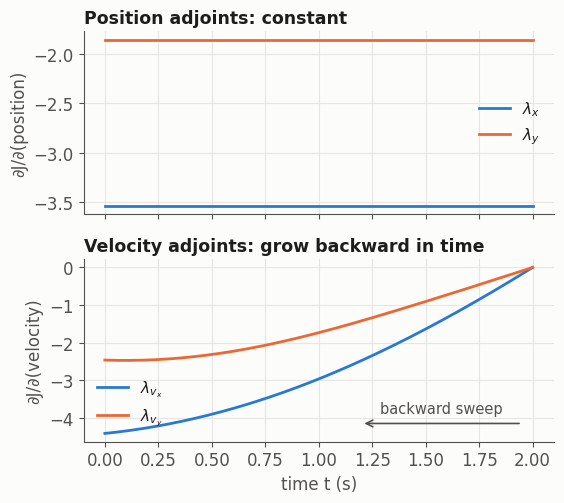

In [34]:
t = np.arange(N + 1) * h
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5.8, 5.2), sharex=True)
ax1.plot(t, lam[:, 0], label=r"$\lambda_x$")
ax1.plot(t, lam[:, 1], label=r"$\lambda_y$")
ax1.set(title="Position adjoints: constant", ylabel="∂J/∂(position)")
ax1.legend(loc="center right")
ax2.plot(t, lam[:, 2], label=r"$\lambda_{v_x}$")
ax2.plot(t, lam[:, 3], label=r"$\lambda_{v_y}$")
ax2.set(title="Velocity adjoints: grow backward in time", xlabel="time t (s)", ylabel="∂J/∂(velocity)")
ax2.legend(loc="lower left")
ax2.annotate("", xy=(1.2, 0.1), xytext=(1.95, 0.1), xycoords=("data", "axes fraction"),
             textcoords=("data", "axes fraction"), arrowprops=dict(arrowstyle="->", color=INK2, lw=1.2))
ax2.text(1.575, 0.16, "backward sweep", transform=ax2.get_xaxis_transform(), color=INK2, fontsize=10.5, ha="center")
fig.tight_layout()

Remember what these numbers mean: $\lambda_k = \partial J/\partial s_k$.

- **The position adjoints** $\lambda_x, \lambda_y$ are exactly constant. The dynamics don't depend on where the ball is, only on how fast it's moving, so nudging the position by 1 cm at any moment simply shifts where it arrives by 1 cm. Their value is the miss vector $\mathbf p_N - \mathbf p^*$.
- **The velocity adjoints** $\lambda_{v_x}, \lambda_{v_y}$ start at zero at the catch and grow (in magnitude) as we go back in time. A velocity kick at time $t$ has $T - t$ seconds to turn into a position error, so early kicks matter more. Without drag this would be exact: $\lambda_{\mathbf v}(t) = (T - t)(\mathbf p_N - \mathbf p^*)$. Drag bends them and makes them smaller, because part of any kick gets damped away before the catch.

The last step turns this into the gradient we want. The inputs only set the initial velocity, so $\nabla_\theta J = D^\top\lambda_0$ just translates "how much a velocity kick at launch matters" into terms of speed and angle.

### Using the gradient

Now that we have this derivative information, we want to use it to optimize the inputs of our simulation. There are many ways of doing this, but for now we'll hand the gradient to an off-the-shelf optimizer, BFGS, which builds up curvature information from successive gradients.

In [35]:
path = [theta_guess.copy()]
res = minimize(J, theta_guess, jac=lambda th: gradient_adjoint(th)[0], method="BFGS",
               callback=lambda th: path.append(th.copy()))
theta_opt, path = res.x, np.array(path)
print(f"optimal throw: v0 = {theta_opt[0]:.3f} m/s at alpha = {np.degrees(theta_opt[1]):.3f} degrees")
print(f"J = {res.fun:.1e} after {res.nit} iterations ({res.njev} gradient evaluations)")

optimal throw: v0 = 21.215 m/s at alpha = 37.995 degrees
J = 8.0e-14 after 8 iterations (11 gradient evaluations)


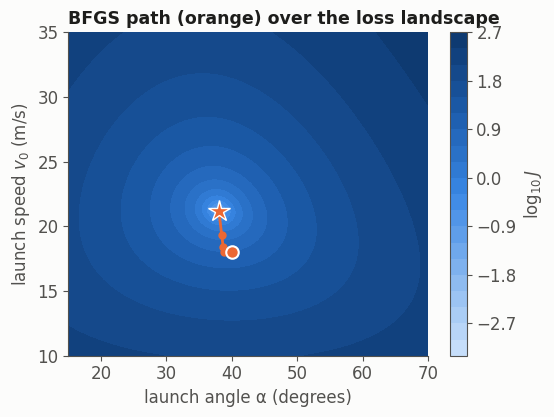

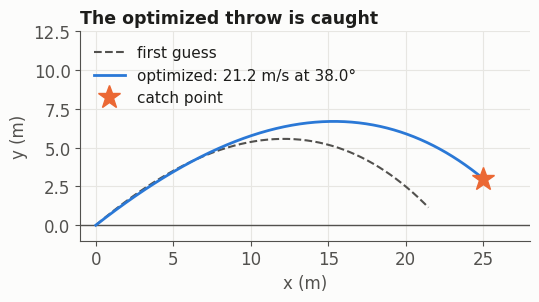

In [36]:
# The loss over a grid of throws. `simulate` works on the whole grid at once.
V0, ALPHA = np.meshgrid(np.linspace(10, 35, 121), np.radians(np.linspace(15, 70, 111)))
final = simulate((V0, ALPHA))[-1]
J_grid = 0.5 * ((final[0] - p_star[0])**2 + (final[1] - p_star[1])**2)

fig, ax = plt.subplots(figsize=(5.8, 4.2))
cs = ax.contourf(np.degrees(ALPHA), V0, np.log10(J_grid), levels=18, cmap=BLUES)
fig.colorbar(cs, ax=ax, label=r"$\log_{10} J$")
ax.plot(np.degrees(path[:, 1]), path[:, 0], color=ORANGE, marker="o", ms=5)
ax.plot(np.degrees(path[0, 1]), path[0, 0], "o", color=ORANGE, ms=9, mec="white", mew=1.5)
ax.plot(np.degrees(theta_opt[1]), theta_opt[0], marker="*", ms=16, color=ORANGE, mec="white", mew=1)
ax.set(xlabel="launch angle α (degrees)", ylabel="launch speed $v_0$ (m/s)", title="BFGS path (orange) over the loss landscape")
ax.grid(False)

traj_opt = simulate(theta_opt)
fig, ax = plt.subplots(figsize=(5.8, 3.3))
ax.axhline(0, color=INK2, lw=1)
ax.plot(traj[:, 0], traj[:, 1], color=INK2, ls="--", lw=1.5, label="first guess")
ax.plot(traj_opt[:, 0], traj_opt[:, 1], color=BLUE,
        label=f"optimized: {theta_opt[0]:.1f} m/s at {np.degrees(theta_opt[1]):.1f}°")
ax.plot(*p_star, marker="*", ms=17, color=ORANGE, ls="none", label="catch point")
ax.set(xlabel="x (m)", ylabel="y (m)", title="The optimized throw is caught", xlim=(-1, 28), ylim=(-1, 12.5))
ax.set_aspect("equal")
ax.legend(loc="upper left")

With only two inputs, the adjoint doesn't save much time-- the payoff in speed comes when there are many inputs.

If you're running this notebook yourself, the next cell lets you play around with the launch speed and angle and see which way the adjoint gradient points. It needs `ipywidgets`.

In [22]:
import io
import ipywidgets as widgets
from IPython.display import display
from matplotlib.figure import Figure

# The plot is drawn on a plain Figure (which pyplot never auto-displays) and shown as an
# image widget. Moving a slider replaces that one image instead of printing a new plot.
v0_slider = widgets.FloatSlider(value=18, min=10, max=35, step=0.5, description="v0 (m/s)")
angle_slider = widgets.FloatSlider(value=40, min=15, max=70, step=1, description="angle (°)")
picture = widgets.Image(format="png", layout=widgets.Layout(max_width="100%"))
eta = 0.8    # step size: the arrow is one gradient-descent step, so its length shows how steep it is

def explore(change=None):
    v0, angle = v0_slider.value, angle_slider.value
    theta = np.array([v0, np.radians(angle)])
    grad, tr, _ = gradient_adjoint(theta)
    fig = Figure(figsize=(11, 4))
    a1, a2 = fig.subplots(1, 2)
    a1.axhline(0, color=INK2, lw=1)
    a1.plot(tr[:, 0], tr[:, 1], color=BLUE)
    a1.plot(*p_star, marker="*", ms=17, color=ORANGE)
    a1.set(xlim=(-1, 35), ylim=(-6, 20), xlabel="x (m)", ylabel="y (m)", title=f"J = {J(theta):.2f}")
    a1.set_aspect("equal")
    a2.contourf(np.degrees(ALPHA), V0, np.log10(J_grid), levels=18, cmap=BLUES)
    grad_plot = np.array([grad[1] * np.pi / 180, grad[0]])   # gradient per degree and per m/s
    step = -eta * grad_plot                                   # one gradient-descent step
    a2.annotate("", xy=(angle + step[0], v0 + step[1]), xytext=(angle, v0),
                arrowprops=dict(arrowstyle="->", color=ORANGE, lw=2.5), annotation_clip=False)
    a2.plot(angle, v0, "o", color=ORANGE, ms=8)
    a2.set(xlabel="angle (degrees)", ylabel="v0 (m/s)", title=f"one gradient step  (|∇J| = {np.linalg.norm(grad_plot):.2f})")
    a2.grid(False)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    picture.value = buf.getvalue()

v0_slider.observe(explore, names="value")
angle_slider.observe(explore, names="value")
explore()
display(widgets.VBox([v0_slider, angle_slider, picture]))

*Note:* the arrow's direction depends on the units we measure the inputs in (here degrees and m/s), so measuring the angle in radians instead would change which way "steepest downhill" points, and since the plot stretches the two axes differently, the arrow won't always look perpendicular to the contours. This sensitivity to scaling is part of why methods like BFGS (which attempt to learn the curvature as they go) tend to do better than plain gradient steps.

## 4. Example B: steering with thrusters (600 inputs)

**The (slightly less) toy problem.** Now let's give the ball thrusters. It's launched from the origin at a fixed velocity of $(12, 12)$ m/s, so there's no throw to choose. Instead, at every time step we can fire the thrusters to add an acceleration $\mathbf u_k \in \mathbb{R}^2$, in m/s². The flight lasts $T = 3$ s, split into $N = 300$ steps, so there are $2 \times 300 = 600$ inputs. We want to:

- arrive at $\mathbf p^* = (30, 0)$ m exactly at time $T$,
- arrive **gently**, with nearly zero velocity,
- steer clear of a round obstacle of radius 1 m centered at $(11, 6.5)$ m, which the unpowered throw flies straight through,
- use as little thrust as possible.

This is an **optimal control** problem. The unknown is a whole function of time, the thrust history, rather than a couple of numbers. Once discretized, it's 600 numbers.

The dynamics are the same as before, with the thrust added to the acceleration:
$$ s_{k+1} = s_k + h\big(f(s_k) + B\,\mathbf u_k\big), \qquad B = \begin{pmatrix} 0 \\ I \end{pmatrix}. $$
Each goal becomes a term in the score:
$$ J = \underbrace{\tfrac{w_p}{2}\big|\mathbf p_N - \mathbf p^*\big|^2}_{\text{hit the target}} + \underbrace{\tfrac{w_v}{2}\big|\mathbf v_N\big|^2}_{\text{arrive gently}} + h\sum_{k=0}^{N-1}\Big[\underbrace{\tfrac{\rho}{2}\,|\mathbf u_k|^2}_{\text{save fuel}} + \underbrace{\phi(\mathbf p_k)}_{\text{avoid obstacle}}\Big]. $$
The obstacle term is a repulsion that switches on within $r = 2$ m of the obstacle's center $\mathbf c$, so it acts as a 1 m buffer around the obstacle itself, and it grows quadratically the deeper you go: $\phi(\mathbf p) = \tfrac{w_{\text{obs}}}{2}\max\big(0,\ r - |\mathbf p - \mathbf c|\big)^2$. It's only a "soft" penalty, so the path is allowed to dip into the buffer, but the buffer is intended to keep it clear of the obstacle. The weights $w_p$, $w_v$, $\rho$ and $w_{\text{obs}}$ set the trade-offs between the goals.

In [38]:
# ---- Example B: setup (same gravity and drag as Example A) ----
T_B = 3.0                                  # flight time, s
s0_B = np.array([0.0, 0.0, 12.0, 12.0])    # fixed launch: from the origin at (12, 12) m/s
p_target = np.array([30.0, 0.0])           # land here, m
w_p, w_v = 100.0, 10.0                     # weights on missing the target / arriving fast
rho = 0.05                                 # price of fuel
obs_c, obs_r, w_obs = np.array([11.0, 6.5]), 2.0, 2000.0   # obstacle centre, repulsion radius, penalty weight
obs_body = 1.0                                             # radius of the obstacle itself, m
B = np.vstack([np.zeros((2, 2)), np.eye(2)])               # thrust acts on the velocity components

def obstacle(p):
    # The penalty phi(p) and its gradient: zero beyond the repulsion radius, quadratic inside it.
    d = p - obs_c
    r = np.linalg.norm(d)
    if r >= obs_r:
        return 0.0, np.zeros(2)
    return 0.5 * w_obs * (obs_r - r)**2, -w_obs * (obs_r - r) * d / r

def simulate_B(U):
    # U has shape (N, 2): one thrust vector per step. Returns the trajectory, shape (N+1, 4).
    h_B = T_B / len(U)
    traj = [s0_B]
    for k in range(len(U)):
        traj.append(traj[-1] + h_B * (f(traj[-1]) + B @ U[k]))
    return np.array(traj)

def J_B(u_flat):
    U = u_flat.reshape(-1, 2)
    h_B = T_B / len(U)
    traj = simulate_B(U)
    cost = 0.5 * w_p * np.sum((traj[-1, :2] - p_target)**2) + 0.5 * w_v * np.sum(traj[-1, 2:]**2)
    for k in range(len(U)):
        cost += h_B * (0.5 * rho * U[k] @ U[k] + obstacle(traj[k, :2])[0])
    return cost

N_B = 300
print(f"{N_B} steps, so {2 * N_B} inputs")

300 steps, so 600 inputs


J with no thrust = 7475


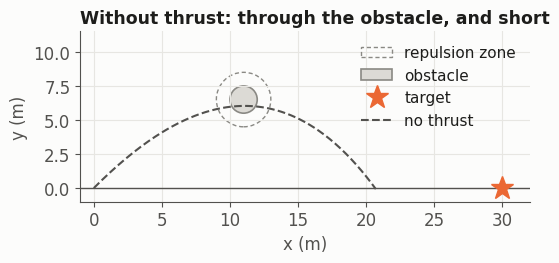

In [39]:
def draw_scene(ax, ytop=11.5):
    ax.axhline(0, color=INK2, lw=1)
    ax.add_patch(plt.Circle(obs_c, obs_r, facecolor="none", edgecolor=OBST_EDGE, lw=1, ls=(0, (3, 2)),
                            zorder=1, label="repulsion zone"))
    ax.add_patch(plt.Circle(obs_c, obs_body, facecolor=OBST_FILL, edgecolor=OBST_EDGE, lw=1.2,
                            zorder=1, label="obstacle"))
    ax.plot(*p_target, marker="*", ms=17, color=ORANGE, ls="none", label="target", zorder=5)
    ax.set(xlabel="x (m)", ylabel="y (m)", xlim=(-1, 32), ylim=(-1, ytop))
    ax.set_aspect("equal")

def above_ground(traj):
    # For display: cut the trajectory where it goes below y = 0.
    below = np.nonzero(traj[1:, 1] < 0)[0]
    return traj[: below[0] + 2] if len(below) else traj

traj_free = simulate_B(np.zeros((N_B, 2)))
fig, ax = plt.subplots(figsize=(5.8, 2.9))
draw_scene(ax)
ax.plot(*above_ground(traj_free)[:, :2].T, color=INK2, ls="--", lw=1.5, label="no thrust")
ax.set_title("Without thrust: through the obstacle, and short")
ax.legend(loc="upper right")
print(f"J with no thrust = {J_B(np.zeros(2 * N_B)):.0f}")

### The adjoint recipe, generalized

Two nuances have been introduced to our rocket-powered ball. The score we use now has a **running cost**. This is a term that contributes cost at each step (as opposed to only at the terminal time). Each step's cost feeds into the backward sweep as an extra "source": $\lambda_k$ picks up $h\,\nabla_s\phi(s_k)$ in addition to $A_k^\top\lambda_{k+1}$. There are also inputs at each step now, not just the initial step. Input $\mathbf u_k$ affects $s_{k+1}$ directly, through $\partial s_{k+1}/\partial\mathbf u_k = hB$, so its gradient is read off from the adjoint one step later.

Putting it together, here's the recipe for Example B next to the one we used for Example A:
$$ \boxed{\begin{array}{l|l|l}
 & \textbf{Example A}\ \ (\theta = (v_0, \alpha)) & \textbf{Example B}\ \ (\theta = \mathbf u_0, \dots, \mathbf u_{N-1}) \\ \hline
\text{start at the end} & \lambda_N = (\mathbf p_N - \mathbf p^*,\ 0,\ 0) & \lambda_N = \big(w_p(\mathbf p_N - \mathbf p^*),\ w_v\,\mathbf v_N\big) \\[6pt]
\text{sweep back, } k = N-1, \dots, 0 & \lambda_k = A_k^\top\lambda_{k+1} & \lambda_k = A_k^\top\lambda_{k+1} + h\,\nabla_s\phi(s_k) \\[6pt]
\text{read off the gradient} & \nabla_\theta J = D^\top\lambda_0 & \dfrac{\partial J}{\partial\mathbf u_k} = h\,B^\top\lambda_{k+1} + h\,\rho\,\mathbf u_k
\end{array}} $$

Since $B^\top$ just picks out the velocity components, $\partial J/\partial\mathbf u_k$ is the velocity part of the adjoint at step $k+1$ plus the fuel term. **All 600 gradient entries come out of a single backward sweep**, as a by-product of the same recursion we already had.

<details>
<summary><b>The general recipe</b></summary>

If each step is $s_{k+1} = \Phi_k(s_k, \theta)$ and the score is $J = \Psi(s_N) + \sum_k \ell_k(s_k, \theta)$, then
$$ \lambda_N = \nabla \Psi(s_N), \qquad \lambda_k = \left(\frac{\partial\Phi_k}{\partial s}\right)^{\!\top}\!\lambda_{k+1} + \nabla_s\ell_k, $$
$$ \frac{dJ}{d\theta} = D^\top\lambda_0 + \sum_{k=0}^{N-1}\left[\left(\frac{\partial\Phi_k}{\partial\theta}\right)^{\!\top}\!\lambda_{k+1} + \nabla_\theta\ell_k\right]. $$
Example A is the case where $\theta$ only enters through $s_0$ and there's no running cost. Example B is the case where $\theta$ is the list of thrusts and each $\mathbf u_k$ enters only step $k$.

</details>

In [40]:
def gradient_adjoint_B(u_flat):
    U = u_flat.reshape(-1, 2)
    N_B = len(U); h_B = T_B / N_B
    traj = simulate_B(U)                                     # forward pass
    lam = np.zeros((N_B + 1, 4))
    lam[N_B, :2] = w_p * (traj[N_B, :2] - p_target)          # starting value at the final step
    lam[N_B, 2:] = w_v * traj[N_B, 2:]
    grad = np.zeros((N_B, 2))
    for k in reversed(range(N_B)):                           # backward pass
        grad[k] = h_B * (B.T @ lam[k + 1]) + h_B * rho * U[k]    # dJ/du_k, read off the sweep
        A_k = np.eye(4) + h_B * df_ds(traj[k])
        source = np.concatenate([obstacle(traj[k, :2])[1], [0.0, 0.0]])
        lam[k] = A_k.T @ lam[k + 1] + h_B * source
    return grad.ravel(), traj, lam

### Checking it, and counting the cost

A full finite-difference check would take 601 simulations, so instead we check the gradient along one random direction $d$. The directional derivative $\nabla J \cdot d$ should match $\big(J(u + \varepsilon d) - J(u - \varepsilon d)\big)/2\varepsilon$.

In [48]:
rng = np.random.default_rng(0)
u_test = rng.normal(scale=3.0, size=2 * N_B)    # an arbitrary thrust history
d = rng.normal(size=2 * N_B)                    # a random direction
eps = 1e-6
fd = (J_B(u_test + eps * d) - J_B(u_test - eps * d)) / (2 * eps)
adj = gradient_adjoint_B(u_test)[0] @ d
print(f"finite differences along d:  {fd:.10f}")
print(f"adjoint gradient . d:        {adj:.10f}")
print(f"relative difference: {abs(fd - adj) / abs(adj):.1e}   ")

finite differences along d:  268.0893958313
adjoint gradient . d:        268.0893972020
relative difference: 5.1e-09   


Now the comparison that matters. We time one gradient computed both ways as the number of steps $N$, and hence the number of inputs $2N$, grows.

In [42]:
def gradient_fd_B(u_flat, eps=1e-6):
    base = J_B(u_flat)
    return np.array([(J_B(u_flat + eps * e) - base) / eps for e in np.eye(len(u_flat))])

def time_it(fn, arg, repeat=3):
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn(arg)
        best = min(best, time.perf_counter() - t0)
    return best

Ns_fd, Ns_adj = [25, 50, 100, 200, 400], [25, 50, 100, 200, 400, 800, 1600]
t_fd = [time_it(gradient_fd_B, np.zeros(2 * n), repeat=1) for n in Ns_fd]
t_adj = [time_it(gradient_adjoint_B, np.zeros(2 * n), repeat=7) for n in Ns_adj]

print("inputs    finite differences    adjoint     speed-up")
for n, a in zip(Ns_adj, t_adj):
    if n in Ns_fd:
        fdt = t_fd[Ns_fd.index(n)]
        print(f"{2 * n:6d}    {fdt:14.3f} s      {a:7.4f} s    {fdt / a:6.0f}x")
    else:
        print(f"{2 * n:6d}    {'(skipped)':>14}        {a:7.4f} s")

inputs    finite differences    adjoint     speed-up
    50             0.008 s       0.0004 s        21x
   100             0.028 s       0.0008 s        37x
   200             0.116 s       0.0015 s        79x
   400             0.564 s       0.0029 s       194x
   800             2.508 s       0.0063 s       400x
  1600         (skipped)         0.0129 s
  3200         (skipped)         0.0248 s


[Text(0.5, 0, 'number of inputs (2N)'),
 Text(0, 0.5, 'time for one gradient (s)'),
 (40, 12800),
 Text(0.0, 1.0, 'Cost of one gradient')]

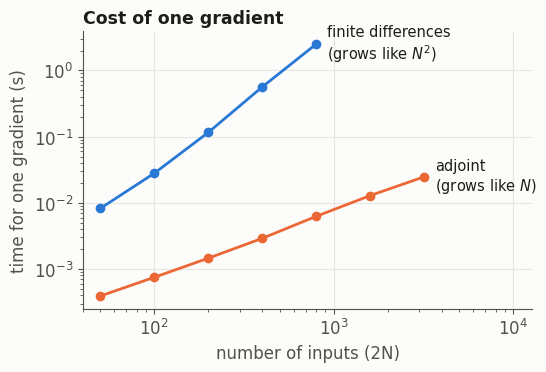

In [43]:
fig, ax = plt.subplots(figsize=(5.8, 3.6))
x_fd, x_adj = 2 * np.array(Ns_fd), 2 * np.array(Ns_adj)
ax.loglog(x_fd, t_fd, color=BLUE, marker="o", ms=6)
ax.loglog(x_adj, t_adj, color=ORANGE, marker="o", ms=6)
ax.text(x_fd[-1] * 1.15, t_fd[-1], "finite differences\n(grows like $N^2$)", color=INK, fontsize=10.5, va="center")
ax.text(x_adj[-1] * 1.15, t_adj[-1], "adjoint\n(grows like $N$)", color=INK, fontsize=10.5, va="center")
ax.set(xlabel="number of inputs (2N)", ylabel="time for one gradient (s)", xlim=(40, 3200 * 4),
       title="Cost of one gradient")

Finite differences grow like $N^2$: each of the $2N$ reruns costs $N$ steps. The adjoint grows like $N$: one forward pass and one backward pass of $N$ steps each. The gap widens without limit as the problem grows, and in real applications, with millions of inputs, finite differences aren't an option at all.

### Optimizing the thrust

With a cheap, exact gradient we can use L-BFGS, a quasi-Newton method designed for problems with many inputs, starting from no thrust at all.

In [44]:
t0 = time.perf_counter()
res_B = minimize(J_B, np.zeros(2 * N_B), jac=lambda u: gradient_adjoint_B(u)[0],
                 method="L-BFGS-B", options={"maxiter": 2000})
elapsed = time.perf_counter() - t0
U_opt = res_B.x.reshape(-1, 2)
_, traj_B, lam_B = gradient_adjoint_B(res_B.x)
n_grads = getattr(res_B, "njev", res_B.nfev)

closest = np.linalg.norm(traj_B[:, :2] - obs_c, axis=1).min()
print(f"L-BFGS: {res_B.nit} iterations, {n_grads} gradient evaluations, {elapsed:.1f} s")
print(f"final position ({traj_B[-1, 0]:.2f}, {traj_B[-1, 1]:.2f}) m, final speed {np.linalg.norm(traj_B[-1, 2:]):.2f} m/s")
print(f"closest approach to the obstacle's centre: {closest:.2f} m "
      f"(obstacle radius {obs_body:.0f} m, repulsion starts at {obs_r:.0f} m)")
print(f"with finite-difference gradients, that's about {n_grads * (2 * N_B + 1):,} simulations instead of {n_grads}")

L-BFGS: 72 iterations, 106 gradient evaluations, 0.7 s
final position (30.00, 0.01) m, final speed 0.14 m/s
closest approach to the obstacle's centre: 1.97 m (obstacle radius 1 m, repulsion starts at 2 m)
with finite-difference gradients, that's about 63,706 simulations instead of 106


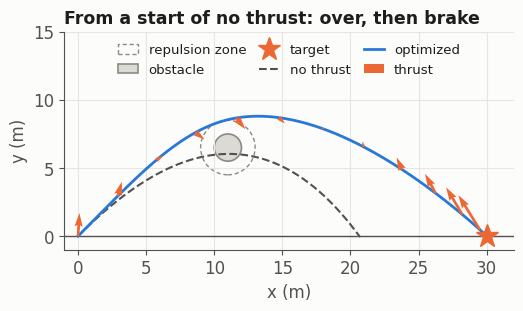

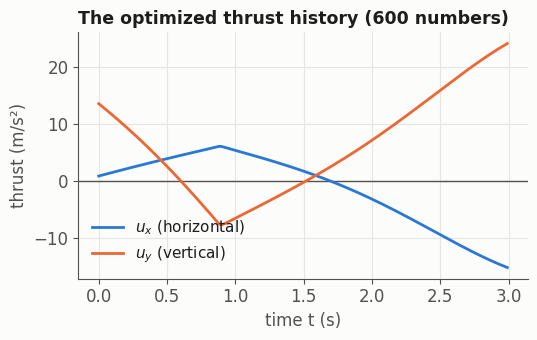

In [45]:
t_B = np.arange(N_B + 1) * (T_B / N_B)
fig, ax = plt.subplots(figsize=(5.8, 3.6))
draw_scene(ax, ytop=15)
ax.plot(*above_ground(traj_free)[:, :2].T, color=INK2, ls="--", lw=1.5, label="no thrust")
ax.plot(traj_B[:, 0], traj_B[:, 1], color=BLUE, label="optimized", zorder=3)
idx = np.arange(0, N_B, 25)
ax.quiver(traj_B[idx, 0], traj_B[idx, 1], U_opt[idx, 0], U_opt[idx, 1], color=ORANGE,
          angles="xy", scale_units="xy", scale=8, width=0.006, zorder=4, label="thrust")
ax.set_title("From a start of no thrust: over, then brake")
ax.legend(loc="upper center", ncol=3, fontsize=9.5, handlelength=1.5, columnspacing=1.0)

fig, ax = plt.subplots(figsize=(5.8, 3.2))
ax.axhline(0, color=INK2, lw=1)
ax.plot(t_B[:-1], U_opt[:, 0], label=r"$u_x$ (horizontal)")
ax.plot(t_B[:-1], U_opt[:, 1], label=r"$u_y$ (vertical)")
ax.set(xlabel="time t (s)", ylabel="thrust (m/s²)", title="The optimized thrust history (600 numbers)")
ax.legend(loc="lower left")

The kink near $t \approx 0.9$ s is where the path briefly dips into the repulsion zone. We'll see why the thrust history bends there in a moment.

### What the adjoint says about the solution

The adjoint's job is to deliver a derivative. What we do with that derivative is a separate choice. Here we gave it to L-BFGS, but the same gradient could drive plain gradient descent, a Newton-type method, or a sensitivity study ("which thrusts matter most?"). Still, the adjoint also tells us something about the solution itself.

Wherever the optimizer stops, the gradient is (nearly) zero, so the boxed formula gives
$$ h\,B^\top\lambda_{k+1} + h\,\rho\,\mathbf u_k = 0 \quad\Longrightarrow\quad \mathbf u_k = -\frac{1}{\rho}\,\lambda_{\mathbf v,\,k+1}. $$
The thrust at each moment points *against* the velocity adjoint, which is the direction in which a velocity kick would most increase the final cost. Its size is set by the price of fuel, $\rho$. We can check this numerically by plotting the optimized thrust on top of $-\lambda_{\mathbf v}/\rho$ computed from the adjoint.

largest mismatch: 6.7e-04 of the peak thrust (limited only by the optimizer's tolerance)


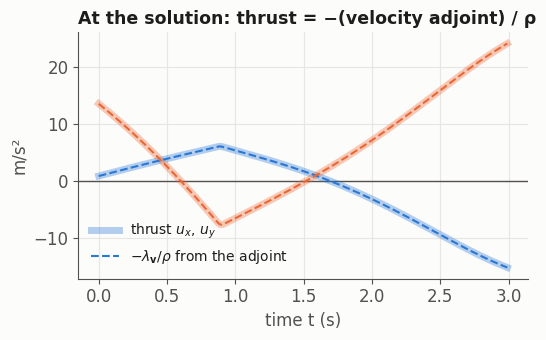

In [46]:
predicted = -lam_B[1:, 2:] / rho
fig, ax = plt.subplots(figsize=(5.8, 3.2))
ax.axhline(0, color=INK2, lw=1)
ax.plot(t_B[:-1], U_opt[:, 0], lw=5, alpha=0.35, color=BLUE, label=r"thrust $u_x$, $u_y$")
ax.plot(t_B[:-1], U_opt[:, 1], lw=5, alpha=0.35, color=ORANGE)
ax.plot(t_B[:-1], predicted[:, 0], color=BLUE, lw=1.5, ls="--", label=r"$-\lambda_{\mathbf{v}}/\rho$ from the adjoint")
ax.plot(t_B[:-1], predicted[:, 1], color=ORANGE, lw=1.5, ls="--")
ax.set(xlabel="time t (s)", ylabel="m/s²", title="At the solution: thrust = −(velocity adjoint) / ρ")
ax.legend(loc="lower left", fontsize=10)
rel = np.abs(U_opt - predicted).max() / np.abs(U_opt).max()
print(f"largest mismatch: {rel:.1e} of the peak thrust (limited only by the optimizer's tolerance)")

The two lie on top of each other. It also explains the kink: the obstacle penalty only feeds into the adjoint while the ball is inside the repulsion zone, so that's when $\lambda_{\mathbf v}$ (and the thrust) abruptly change slope.

### Some caveats

 The adjoint depends on the whole trajectory, and the trajectory depends on the thrust. So the equation says the thrust and the adjoint must be *consistent* with each other: the forward equation for the state and the backward equation for the adjoint are coupled. Solving that coupled system still takes work, which is what the optimizer did.


Also (without extra assumptions) there's no guarantee the solution one finds is unique, nor any guarantee on it being a global minimum. Starting the optimizer from a different guess, with the thrusters pushing down for the first second, finds a path that goes *under* the obstacle instead.

over :  J = 11.791   thrust vs -lambda_v/rho mismatch 7e-04
under:  J =  8.343   thrust vs -lambda_v/rho mismatch 9e-04


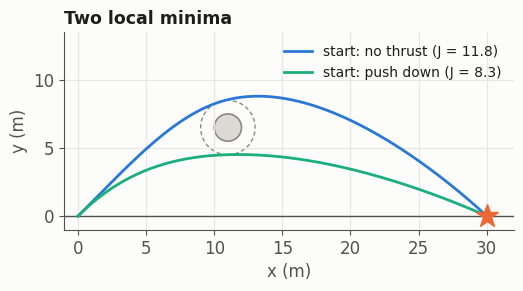

In [47]:
u_start = np.zeros((N_B, 2))
u_start[:100, 1] = -8.0          # push down for the first second
res_under = minimize(J_B, u_start.ravel(), jac=lambda u: gradient_adjoint_B(u)[0],
                     method="L-BFGS-B", options={"maxiter": 3000})
U_under = res_under.x.reshape(-1, 2)
_, traj_under, lam_under = gradient_adjoint_B(res_under.x)

for name, U_, lam_, J_ in [("over ", U_opt, lam_B, res_B.fun), ("under", U_under, lam_under, res_under.fun)]:
    mismatch = np.abs(U_ + lam_[1:, 2:] / rho).max() / np.abs(U_).max()
    print(f"{name}:  J = {J_:6.3f}   thrust vs -lambda_v/rho mismatch {mismatch:.0e}")

fig, ax = plt.subplots(figsize=(5.8, 3.3))
draw_scene(ax, ytop=13.5)
l1, = ax.plot(traj_B[:, 0], traj_B[:, 1], color=BLUE, label=f"start: no thrust (J = {res_B.fun:.1f})")
l2, = ax.plot(traj_under[:, 0], traj_under[:, 1], color=AQUA, label=f"start: push down (J = {res_under.fun:.1f})")
ax.set_title("Two local minima")
ax.legend(handles=[l1, l2], loc="upper right", fontsize=10)

The path under the obstacle is actually *cheaper*, and the optimizer had no way of knowing that from where it started. Both solutions satisfy the adjoint condition equally well. The gradient, and therefore the adjoint, is local information: it tells you which way is downhill from where you stand, not where the deepest valley is. Getting a global answer takes something extra, such as many starting points, a convex problem, or insight into the problem's structure.

The condition $u_k = -\frac{1}{\rho}\,\lambda_{\mathbf v,\,k+1}$ is the discrete form of **Pontryagin's maximum principle** from optimal control, where the adjoint goes by the name "costate". Like a zero gradient in ordinary calculus, it's a *necessary* condition for optimality, not a sufficient one. The forward–backward structure it describes will keep coming back in this series.

## 5. Recap

- An **adjoint method** computes the gradient of a scalar output of a long computation by running the computation forward, then sweeping a single vector backward. The cost is about two runs **regardless of the number of inputs**. The price is storing the forward trajectory.
- Mathematically it's just the **chain rule**, with the product of Jacobians multiplied starting from the output end. The adjoint $\lambda_k = \partial J/\partial s_k$ measures how sensitive the final score is to a nudge in the state at step $k$.
- **The recipe:** start from $\lambda_N = \nabla \Psi(s_N)$; sweep back with $\lambda_k = A_k^\top\lambda_{k+1}$, plus a source term for any running cost; the gradient with respect to any input is (how that input enters a step)$^\top$ times (the adjoint just after that step).
- It gives the **exact** gradient of the discrete computation, with no step size to tune and no truncation error.
- The adjoint delivers a **derivative**, which any gradient-based method can use. In control problems, a zero gradient ties the control to the adjoint ($\mathbf u_k = -\lambda_{\mathbf v,k+1}/\rho$ here). That's a necessary condition for a **local** optimum, not a guarantee of the best one.

### When the adjoint isn't the right tool

Adjoints win decisively when there are many inputs and one output, but they have real costs. Here's how they compare with finite differences.

| | Adjoint (reverse mode) | Finite differences |
|---|---|---|
| Cost per gradient | about 2 runs, whatever the number of inputs | $p + 1$ runs |
| Accuracy | exact for the discrete computation | about half the digits; step size needs tuning |
| Implementation | every step must be differentiated (by hand or with autodiff) and kept in sync with the model | none; works on black-box code |
| Memory | must store or recompute the forward trajectory | one run's worth |
| Parallelism | the backward sweep is sequential | the $p + 1$ runs are independent |
| Many outputs | one backward sweep *per output* | one set of runs covers every output |
| Kinks, contacts, if-statements | derivative can be undefined or misleading | same problem, but it still returns a number |

With **few inputs and many outputs**, forward mode (or finite differences) is the better fit, because the adjoint's cost scales with the number of outputs instead. It's also increasingly common to use "automatic differentiation" tools as opposed to writing adjoints by hand. Automatic-differentiation tools such as JAX and PyTorch generate them, which removes the implementation burden (but not the memory cost).

Some limitations belong to gradients themselves, so no method escapes them. Gradients are local, as Example B showed. In chaotic systems over long time horizons, the exact gradient becomes so large and erratic that it stops being useful for optimization.

**Next, in Part 2:** a neural network's forward pass is the same kind of loop, $s_{k+1} = \Phi_k(s_k, \theta_k)$. The "state" is the vector of activations at layer $k$, and the "inputs" are each layer's weights, which enter at every step just like the thrusts $\mathbf u_k$ did here. Keep the boxed recipe from Example B handy.